# Dataset和Dataloader

In [1]:
!pip list|grep kaggle

kaggle                                   2.0.2
kagglehub                                1.0.2
kagglesdk                                0.1.23


In [2]:
import json
#username和key改为自己的kaggle的，如果不行，就可以直接用这个
token = {"username":"cromy","key":"KGAT_38ceefebb3ff04a48bc24df71aa0c938"}
with open('/content/kaggle.json', 'w') as file:
  json.dump(token, file)#json.dump类似于write

In [3]:
!mkdir -p ~/.kaggle
!cp /content/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle config set -n path -v /content

- path is now set to: /content


In [4]:
!kaggle datasets download -d slothkong/10-monkey-species

Dataset URL: https://www.kaggle.com/datasets/slothkong/10-monkey-species
License(s): CC0-1.0
100% 547M/547M [00:31<00:00, 18.4MB/s]



In [5]:
!unzip -o -d /content /content/datasets/slothkong/10-monkey-species/10-monkey-species.zip

Archive:  /content/datasets/slothkong/10-monkey-species/10-monkey-species.zip
  inflating: /content/monkey_labels.txt  
  inflating: /content/training/training/n0/n0018.jpg  
  inflating: /content/training/training/n0/n0019.jpg  
  inflating: /content/training/training/n0/n0020.jpg  
  inflating: /content/training/training/n0/n0021.jpg  
  inflating: /content/training/training/n0/n0022.jpg  
  inflating: /content/training/training/n0/n0023.jpg  
  inflating: /content/training/training/n0/n0024.jpg  
  inflating: /content/training/training/n0/n0025.jpg  
  inflating: /content/training/training/n0/n0026.jpg  
  inflating: /content/training/training/n0/n0027.jpg  
  inflating: /content/training/training/n0/n0028.jpg  
  inflating: /content/training/training/n0/n0029.jpg  
  inflating: /content/training/training/n0/n0030.jpg  
  inflating: /content/training/training/n0/n0031.jpg  
  inflating: /content/training/training/n0/n0032.jpg  
  inflating: /content/training/training/n0/n0033.jpg  


In [7]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# 设置数据预处理操作，包括将图片缩放到224x224，并将其转换为Tensor，以及归一化
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    # transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# 使用ImageFolder分别读取训练集和验证集
train_dataset = datasets.ImageFolder(
    root='training/training',  # 指向训练集文件夹
    transform=transform
)
val_dataset = datasets.ImageFolder(
    root='validation/validation',  # 指向验证集文件夹
    transform=transform
)

# 创建训练集和验证集的DataLoader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

# 示范访问训练集的部分batch
for images, labels in train_loader:
    print("Train batch:", images.shape, labels)
    break  # 只打印第一个batch的内容

# 示范访问验证集的部分batch
for images, labels in val_loader:
    print("Validation batch:", images.shape, labels)
    break  # 只打印第一个batch的内容

Train batch: torch.Size([32, 3, 224, 224]) tensor([5, 2, 0, 0, 2, 3, 9, 5, 5, 9, 1, 9, 3, 3, 3, 0, 1, 8, 4, 3, 5, 5, 2, 0,
        6, 4, 6, 1, 1, 4, 7, 1])
Validation batch: torch.Size([32, 3, 224, 224]) tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 1, 1, 1, 1, 1])


In [8]:
train_dataset[0][0].shape

torch.Size([3, 224, 224])

In [9]:
import torch
import torch.nn as nn
from torchvision import models

# 自定义ResNet50微调类，将最后的全连接层修改为10分类
class CustomResNet50(nn.Module):
    def __init__(self, num_classes=10, weights=models.ResNet50_Weights.IMAGENET1K_V2):
        super().__init__()
        # 加载预训练模型
        self.base = models.resnet50(weights=weights)
        # 替换全连接层为10分类
        in_features = self.base.fc.in_features
        self.base.fc = nn.Linear(in_features, num_classes)

        # 冻结所有参数
        for param in self.base.parameters():
            param.requires_grad = False

        # 只解冻layer4[2].conv3这一层（即最后一块的第三个block的conv3）
        # ResNet50 layer4有3个block，每个block有conv1/conv2/conv3
        # conv3就是bottleneck的最后一个1x1卷积
        # 如果打印结构可以这样获取
        layer = self.base.layer4[2].conv3  # Conv2d(512, 2048, ...)
        for param in layer.parameters():
            param.requires_grad = True

        # 也解冻最后的fc层，以便于finetune
        for param in self.base.fc.parameters():
            param.requires_grad = True

    def forward(self, x):
        return self.base(x)

# 实例化模型
model = CustomResNet50(num_classes=10)

# 打印模型结构确认
print(model)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 223MB/s]


CustomResNet50(
  (base): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
      

In [10]:
# 统计模型参数量
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

total_params = count_parameters(model)
print(f"模型参数总数: {total_params}")

模型参数总数: 1069066


Epoch [1/10], Train Loss: 0.0368, Train Acc: 99.91%, Val Loss: 0.0660, Val Acc: 98.90%
Best model saved at epoch 1.
Epoch [2/10], Train Loss: 0.0329, Train Acc: 100.00%, Val Loss: 0.0676, Val Acc: 99.26%
No improvement. Early stop counter: 1/5
Epoch [3/10], Train Loss: 0.0316, Train Acc: 100.00%, Val Loss: 0.0581, Val Acc: 99.63%
Best model saved at epoch 3.
Epoch [4/10], Train Loss: 0.0312, Train Acc: 100.00%, Val Loss: 0.0537, Val Acc: 99.63%
Best model saved at epoch 4.
Epoch [5/10], Train Loss: 0.0269, Train Acc: 100.00%, Val Loss: 0.0512, Val Acc: 99.63%
Best model saved at epoch 5.
Epoch [6/10], Train Loss: 0.0233, Train Acc: 100.00%, Val Loss: 0.0507, Val Acc: 99.26%
Best model saved at epoch 6.
Epoch [7/10], Train Loss: 0.0259, Train Acc: 100.00%, Val Loss: 0.0539, Val Acc: 99.63%
No improvement. Early stop counter: 1/5
Epoch [8/10], Train Loss: 0.0222, Train Acc: 100.00%, Val Loss: 0.0493, Val Acc: 98.90%
Best model saved at epoch 8.
Epoch [9/10], Train Loss: 0.0165, Train Acc

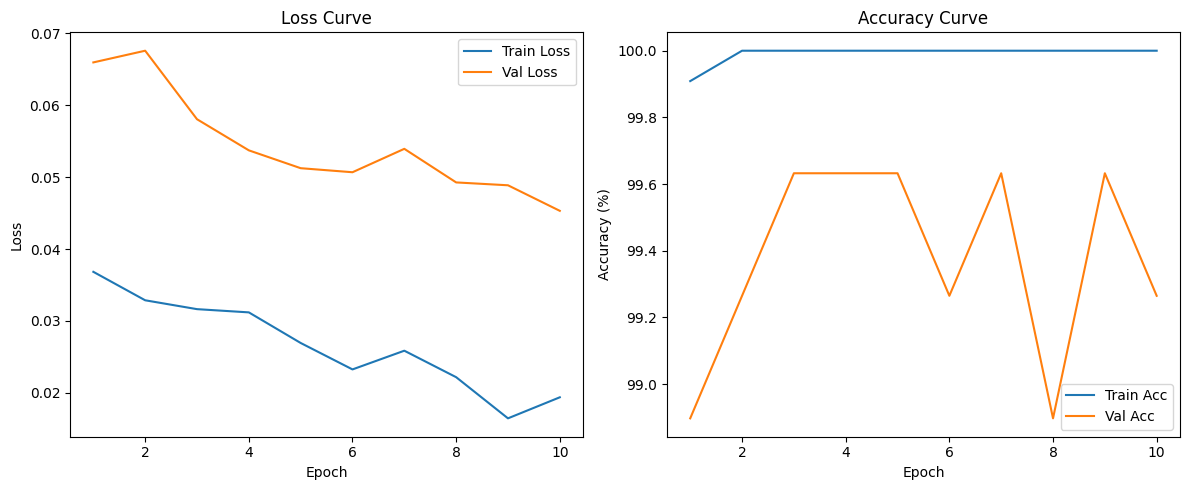

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from model_train import Trainer

# 判断设备：如果有GPU则用GPU，否则用CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# 定义损失函数和优化器
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

# 假设你已经有trainloader和valloader
trainer = Trainer(
    model=model,
    trainloader=train_loader,
    valloader=val_loader,
    optimizer=optimizer,
    device = device,
    early_stop=True,
    patience=5,
    save_path='10monkeys_model.pth'
)

# 训练模型，例如训练10轮
trainer.train(epochs=10)

# 在验证集上评估
val_acc,val_loss = trainer.evaluating(trainer.valloader)
print(f"验证集损失: {val_loss:.4f}, 验证集准确率: {val_acc:.4f}")

# 画出训练和验证过程中的损失与准确率曲线
import matplotlib.pyplot as plt

epochs = range(1, len(trainer.train_losses) + 1)

# plt.figure(figsize=(12,5))
# plt.subplot(1,2,1)
# plt.plot(epochs, trainer.train_losses, label='Train Loss')
# plt.plot(epochs, trainer.val_losses, label='Val Loss')
# plt.xlabel('Epoch')
# plt.ylabel('Loss')
# plt.title('Loss Curve')
# plt.legend()

# plt.subplot(1,2,2)
# plt.plot(epochs, trainer.train_accuracies, label='Train Acc')
# plt.plot(epochs, trainer.val_accuracies, label='Val Acc')
# plt.xlabel('Epoch')
# plt.ylabel('Accuracy')
# plt.title('Accuracy Curve')
# plt.legend()
trainer.plot_metrics()

plt.show()